In [1]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import flox.xarray

from graphufs.stacked_utils import get_channel_index
from prototypes.ocn_only.emulator import OcnTrainer

In [2]:
def cross_covariance_looped(da: xr.DataArray, dim: str = "channels", norm = False):
  """
  Calculates the cross-covariance matrix for all pairs along dim.

  Args:
    da (xr.DataArray): The input DataArray.
    dim (str): The shared dimension along which variables are defined.
    norm (bool): If true, normalization by std will be applied to compute correlation

  Returns:
    xr.DataArray: A DataArray containing the cov/corr matrix.
  """

  channels = da[dim]  # Get the dim values 
  out_mat = np.zeros((len(channels), len(channels)))
  
  for i in range(len(channels)):
    print("i = ", i)
    for j in range(i, len(channels)):
      print("j = ", j)
      channel_i = channels[i]
      channel_j = channels[j]

      # Calculate covariance
      if not norm:
          out_mat[i, j] = xr.cov(da.isel({dim:channel_i}), 
                                 da.isel({dim:channel_j}),
                                 dim = "sample").mean(["lat","lon"], skipna=True)
          statistic = "covariance"
      else:
          out_mat[i, j] = xr.corr(da.isel({dim:channel_i}), 
                                  da.isel({dim:channel_j}),
                                  dim = "sample").mean(["lat","lon"], skipna=True)
          statistic = "correlation"

      # apply symmetry
      out_mat[j, i] = out_mat[i, j].copy()

  # convert to dataArray
  out_da = xr.DataArray(out_mat, 
                        dims=["channels_x","channels_y"], 
                        coords={"channels_x":channels.values, "channels_y":channels.values}, 
                        attrs={"description":f"tendency {statistic}"})
  return out_da

In [3]:
def cross_covariance(da: xr.DataArray, dim: str = "channels", norm: bool = False):
    """
    Calculates the cross-covariance or cross-correlation matrix for all pairs 
    along dim.

    Args:
        da (xr.DataArray): The input DataArray, which should be loaded into memory.
                           ('sample', 'lat', 'lon', 'channels').
        dim (str): The dimension along which variables are defined (e.g., "channels").
        norm (bool): If true, compute correlation instead of covariance.

    Returns:
        xr.DataArray: A DataArray containing the full covariance or correlation matrix.
    """

    n_samples = da.sizes["sample"]

    if not norm:
        statistic = "covariance"
        # For covariance, the one-pass demean -> dot product is stable and correct.
        da_demeaned = da - da.mean(dim="sample", skipna=True)
        da1 = da_demeaned.rename({dim: f"{dim}_x"})
        da2 = da_demeaned.rename({dim: f"{dim}_y"})
        cov_map = xr.dot(da1, da2, dims="sample") / (n_samples - 1)
        out_matrix = cov_map.mean(["lat", "lon"], skipna=True)

    else:
        statistic = "correlation"
        # We first z-score the data and then compute the covariance of the result.
        
        # 1. Calculate mean and sample standard deviation (with ddof=1).
        mean = da.mean(dim="sample", skipna=True)
        std = da.std(dim="sample", skipna=True, ddof=1)
        #epsilon = 1e-12

        # 2. Z-score the data.
        da_zscored = (da - mean) / std

        # 3. The correlation is the covariance of the z-scored data.
        da1 = da_zscored.rename({dim: f"{dim}_x"})
        da2 = da_zscored.rename({dim: f"{dim}_y"})
        
        # The dot product of z-scored data, divided by (n-1), is the correlation map.
        corr_map = xr.dot(da1, da2, dims="sample") / (n_samples - 1)
        
        # 4. Average the correlation map over spatial dimensions.
        out_matrix = corr_map.mean(["lat", "lon"], skipna=True)

    out_matrix.attrs = {"description": f"tendency {statistic}"}
    
    return out_matrix

In [4]:
def plot_correlation(ax, da: xr.DataArray, 
                     meta: dict = None,
                     ticks: tuple = (0, 1, 8, 15, 22),
                     title: str = None,
                     vmin: float = None, 
                     vmax: float = None,
                    ):
    da.plot(ax=ax, cmap="RdBu_r", vmin=vmin, vmax=vmax)
    ax.set_xticks(ticks,); ax.set_yticks(ticks,)
    if meta is not None:
        ticklabels = [meta[i]["varname"] for i in ticks]   
        ax.set_xticklabels(ticklabels,)
        ax.set_yticklabels(ticklabels,)
        ax.tick_params(labelrotation=45)
    if title is not None:
        ax.set_title(title)
    return  

In [5]:
# Meta Data
_scratch = "/pscratch/sd/n/nagarwal/"
_prototype = "ocn-only"
_expt = "R5" 
_sub_expt = "T1M"
_prototype_home = "/global/homes/n/nagarwal/graph-ufs/prototypes/"
_training_dir = os.path.join(_scratch, _prototype, _expt, "training")

target_lead_time = 24 # in hours
delta_t_data = 6 # in hours
num_missing_samples = 0 if target_lead_time == 6 else 3  # 0 for 6h and 3 for 24h
remove_seasonality = False
training_dates = ["1993-12-31T18", "2019-12-31T18"]

In [6]:
# Open Targets 
fname = "targets.zarr"
ds = xr.open_zarr(os.path.join(_training_dir, fname))
ds

<xarray.Dataset> Size: 650GB
Dimensions:   (channels: 29, lat: 192, lon: 384, sample: 37978)
Coordinates:
  * channels  (channels) int64 232B 0 1 2 3 4 5 6 7 ... 21 22 23 24 25 26 27 28
  * lat       (lat) float64 2kB 89.82 88.89 87.95 87.01 ... -87.25 -88.18 -89.12
  * lon       (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
  * sample    (sample) int64 304kB 0 1 2 3 4 5 ... 37973 37974 37975 37976 37977
Data variables:
    targets   (sample, lat, lon, channels) float64 650GB dask.array<chunksize=(1, 192, 384, 29), meta=np.ndarray>

In [7]:
# Channel Meta Data
_inference_dir = os.path.join(_scratch, _prototype, _expt,
                              f"inference_{_sub_expt}", "validation")
fname = "graphufs.240h.zarr"
ds_pred = xr.open_zarr(os.path.join(_inference_dir, fname))
meta_targets = get_channel_index(ds_pred, preserved_dims=("time","lead_time","lat","lon"))
meta_targets

{0: {'varname': 'SSH'},
 1: {'varname': 'so', 'z_l': 0},
 2: {'varname': 'so', 'z_l': 1},
 3: {'varname': 'so', 'z_l': 2},
 4: {'varname': 'so', 'z_l': 3},
 5: {'varname': 'so', 'z_l': 4},
 6: {'varname': 'so', 'z_l': 5},
 7: {'varname': 'so', 'z_l': 6},
 8: {'varname': 'temp', 'z_l': 0},
 9: {'varname': 'temp', 'z_l': 1},
 10: {'varname': 'temp', 'z_l': 2},
 11: {'varname': 'temp', 'z_l': 3},
 12: {'varname': 'temp', 'z_l': 4},
 13: {'varname': 'temp', 'z_l': 5},
 14: {'varname': 'temp', 'z_l': 6},
 15: {'varname': 'uo', 'z_l': 0},
 16: {'varname': 'uo', 'z_l': 1},
 17: {'varname': 'uo', 'z_l': 2},
 18: {'varname': 'uo', 'z_l': 3},
 19: {'varname': 'uo', 'z_l': 4},
 20: {'varname': 'uo', 'z_l': 5},
 21: {'varname': 'uo', 'z_l': 6},
 22: {'varname': 'vo', 'z_l': 0},
 23: {'varname': 'vo', 'z_l': 1},
 24: {'varname': 'vo', 'z_l': 2},
 25: {'varname': 'vo', 'z_l': 3},
 26: {'varname': 'vo', 'z_l': 4},
 27: {'varname': 'vo', 'z_l': 5},
 28: {'varname': 'vo', 'z_l': 6}}

## Assign datetime to each sample

In [8]:
start = pd.Timestamp(training_dates[0])
end = pd.Timestamp(training_dates[1])
targets_time = pd.date_range(
    start=start+pd.Timedelta(target_lead_time, "h"),
    end=end - num_missing_samples*pd.Timedelta(delta_t_data, "h"), # this is due to the incorrect input_overlap value during batching
    freq="6h",
    inclusive="both",
)
targets_time

DatetimeIndex(['1994-01-01 18:00:00', '1994-01-02 00:00:00',
               '1994-01-02 06:00:00', '1994-01-02 12:00:00',
               '1994-01-02 18:00:00', '1994-01-03 00:00:00',
               '1994-01-03 06:00:00', '1994-01-03 12:00:00',
               '1994-01-03 18:00:00', '1994-01-04 00:00:00',
               ...
               '2019-12-28 18:00:00', '2019-12-29 00:00:00',
               '2019-12-29 06:00:00', '2019-12-29 12:00:00',
               '2019-12-29 18:00:00', '2019-12-30 00:00:00',
               '2019-12-30 06:00:00', '2019-12-30 12:00:00',
               '2019-12-30 18:00:00', '2019-12-31 00:00:00'],
              dtype='datetime64[ns]', length=37978, freq='6h')

In [9]:
# assign this date to targets as a potential coord
ds = ds.assign_coords(datetime=("sample", targets_time.values,))
ds

<xarray.Dataset> Size: 650GB
Dimensions:   (channels: 29, lat: 192, lon: 384, sample: 37978)
Coordinates:
  * channels  (channels) int64 232B 0 1 2 3 4 5 6 7 ... 21 22 23 24 25 26 27 28
  * lat       (lat) float64 2kB 89.82 88.89 87.95 87.01 ... -87.25 -88.18 -89.12
  * lon       (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
  * sample    (sample) int64 304kB 0 1 2 3 4 5 ... 37973 37974 37975 37976 37977
    datetime  (sample) datetime64[ns] 304kB 1994-01-01T18:00:00 ... 2019-12-31
Data variables:
    targets   (sample, lat, lon, channels) float64 650GB dask.array<chunksize=(1, 192, 384, 29), meta=np.ndarray>

## Subsample

In [10]:
factor = int(target_lead_time / delta_t_data)
steps_per_day = int(24 / target_lead_time)
num_years = 6
end_index = 365 * num_years * factor * steps_per_day if factor < 4 else None
ds = ds.isel(sample=slice(None, end_index, factor)).astype("float32")

## Tendency

In [ ]:
# Compute Tendency
ds = ds.diff(dim="sample")
ds

In [11]:
# Select a variable and convert to DataArray
varname = "targets" if "targets" in ds.variables else list(ds.data_vars)[0]
da = ds[varname]

## Compute seasonality and deseason

In [ ]:
seasonality = da.groupby('datetime.month').mean()
da = da.groupby('datetime.month') - seasonality
da.load()

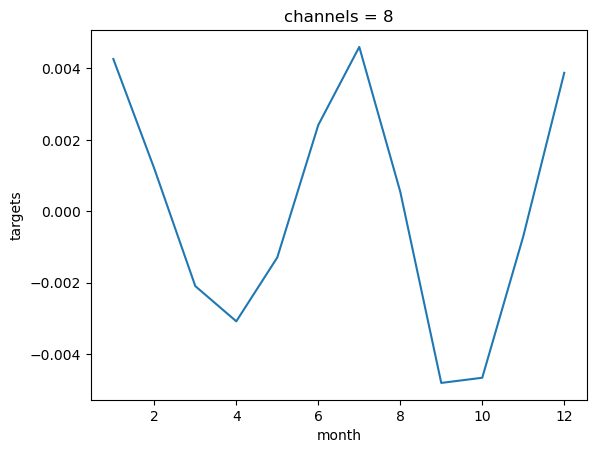

In [13]:
seasonality.isel(channels=8).mean(("lat","lon")).plot()
plt.show()

In [14]:
sst_tendency_deseasoned = da.isel(channels=8).mean(("lat", "lon"))

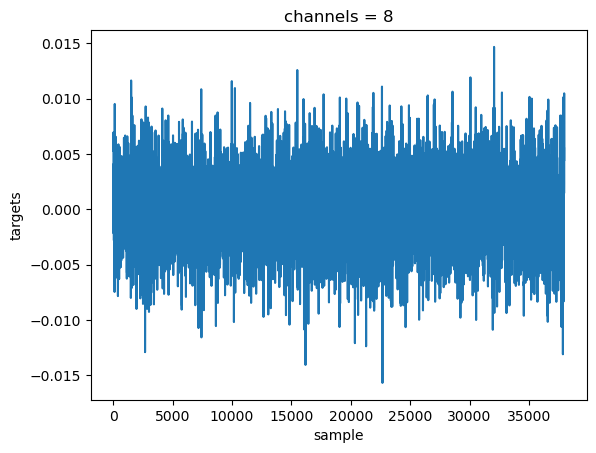

In [15]:
sst_tendency_deseasoned.plot()
plt.show()

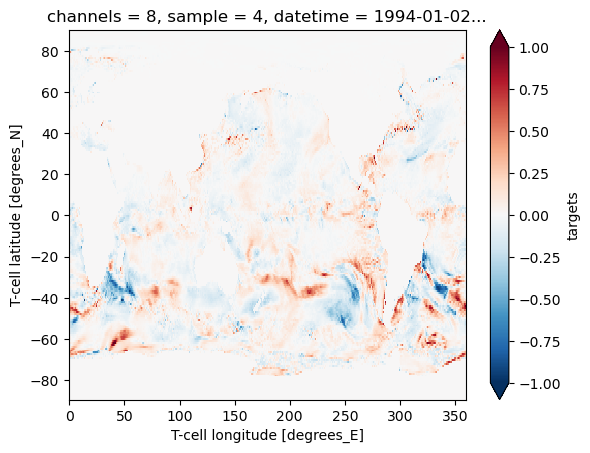

In [18]:
# plot any one snapshot
da.isel(channels=8, sample=0).plot(vmin=-1, vmax=1, cmap="RdBu_r")
plt.show()

## Compute Covariance

In [13]:
# Define the DataArray to work on depending on whether the seasonality 
# is removed or not
norm = True
da.load()

# Eagerly compute the covariance
out = cross_covariance(da, dim="channels", norm=norm).compute()

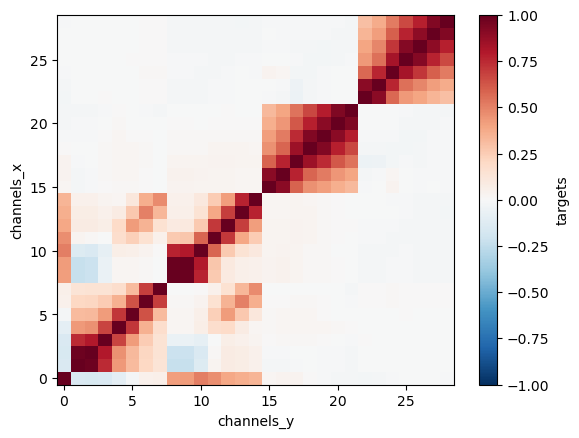

In [14]:
# Plot 
out.plot()
plt.show()

In [15]:
np.trace(out.values)

np.float32(29.0)

In [16]:
# Convert to dataset and write to disk
name = "correlation" if norm else "covariance"
ds_out = out.to_dataset(name="targets")

In [18]:
# Define the file name
seasonality_suffix = "rm_seasonality" if remove_seasonality else "seasonality_intact"
output_file = f"./tendency_{name}_ocn_only_{target_lead_time}h_{seasonality_suffix}.nc"

In [21]:
# Save to file
ds_out.to_netcdf(output_file)
print(f"Saved {name} matrix to {output_file}")

Saved correlation matrix to ./Full_temporal_correlation_ocn_only_seasonality_intact.nc


## Open saved covariance/correlation

In [18]:
file_loc = "/global/homes/n/nagarwal/graph-ufs/prototypes/ocn_only"
cov_file_name = "tendency_covariance_ocn_only_6h.nc"
corr_file_name = "tendency_correlation_ocn_only_6h.nc"

In [19]:
# open file
f = xr.open_dataset(os.path.join(file_loc, corr_file_name))
f

<xarray.Dataset> Size: 7kB
Dimensions:     (channels_x: 29, channels_y: 29)
Coordinates:
  * channels_x  (channels_x) int64 232B 0 1 2 3 4 5 6 7 ... 22 23 24 25 26 27 28
  * channels_y  (channels_y) int64 232B 0 1 2 3 4 5 6 7 ... 22 23 24 25 26 27 28
Data variables:
    targets     (channels_x, channels_y) float64 7kB ...

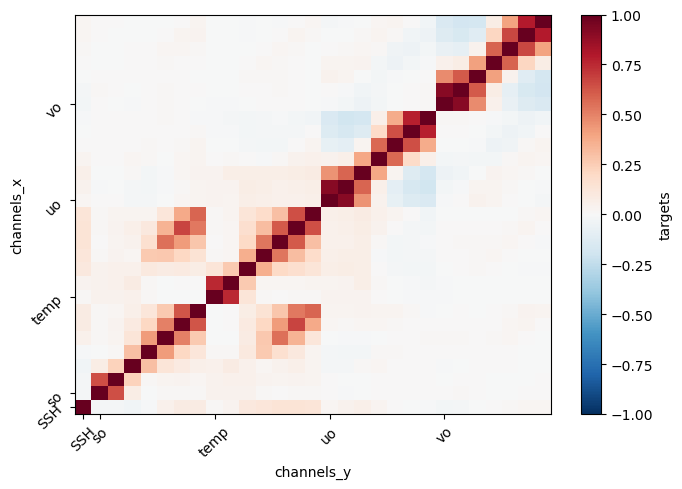

In [20]:
# plot
fig, ax = plt.subplots(1, 1, figsize=(7,5))
f.targets.plot(ax=ax, cmap="RdBu_r",)
ticks = (0, 1, 8, 15, 22,)
#ticklabels = []
#for idx, i in enumerate(ticks):
#    var_name = meta_targets[i]['varname']
#    label = f"{var_name}"
#    if "z_l" in meta_targets[i]:
#        label += f"_z{meta_targets[i]['z_l']}"
#    ticklabels.append(label)
ticklabels = [meta_targets[i]["varname"] for i in ticks]   
ax.set_xticks(ticks,); ax.set_yticks(ticks,)
ax.set_xticklabels(ticklabels,); ax.set_yticklabels(ticklabels,)
ax.tick_params(labelrotation=45)
plt.tight_layout()
#plt.savefig(f"./figures/tendency_correlation_24h.png", dpi=300)
plt.show()

## Compare 6h and 24h correlation matrices

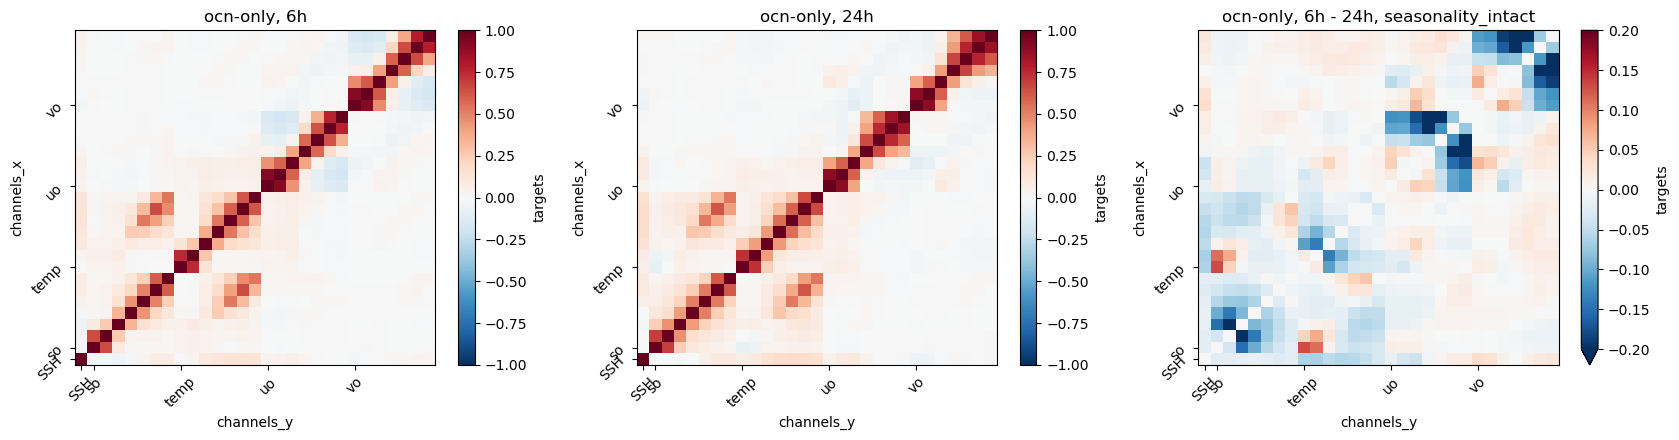

In [21]:
time_steps = ["6h", "24h"]
file_loc = "/global/homes/n/nagarwal/graph-ufs/prototypes/ocn_only"
seasonality_suffix = "seasonality_intact"

corr = {}

fig, ax = plt.subplots(1, 3, figsize=(17,4.5))

for i, ts in enumerate(time_steps):
    fname = f"tendency_correlation_ocn_only_{ts}_{seasonality_suffix}.nc"
    f = xr.open_dataset(os.path.join(file_loc, fname))
    corr[ts] = f.targets
    _ = plot_correlation(ax[i], corr[ts], meta=meta_targets,
                         title=f"ocn-only, {ts}")

# plot the difference in the third panel
diff = corr["6h"] - corr["24h"]
_ = plot_correlation(ax[2], diff, meta=meta_targets,
                     title=f"ocn-only, 6h - 24h, {seasonality_suffix}",
                     vmin=-0.2, vmax=0.2,
                    )

plt.tight_layout()
plt.savefig(f"./figures/compare_correlations_6h_24h_{seasonality_suffix}.png", dpi=300)
plt.show()

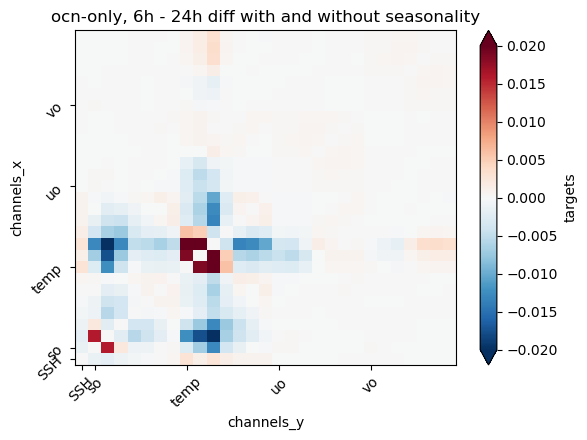

In [16]:
file_loc = "/global/homes/n/nagarwal/graph-ufs/prototypes/ocn_only"
seasonality_suffix = ["seasonality_intact", "rm_seasonality"]

diff6h24h = {}

fig, ax = plt.subplots(1, 1, figsize=(6,4.5))

for i, ss in enumerate(seasonality_suffix):
    fname = f"tendency_correlation_ocn_only_6h_{ss}.nc"
    f6h = xr.open_dataset(os.path.join(file_loc, fname))

    fname = f"tendency_correlation_ocn_only_24h_{ss}.nc"
    f24h = xr.open_dataset(os.path.join(file_loc, fname))
    
    # difference
    diff6h24h[ss] = f24h.targets - f6h.targets
    
diff = diff6h24h["seasonality_intact"] - diff6h24h["rm_seasonality"]
_ = plot_correlation(ax, diff, meta=meta_targets,
                     title=f"ocn-only, 6h - 24h diff with and without seasonality",
                     vmin=-0.02, vmax=0.02,)
plt.tight_layout()
plt.show()

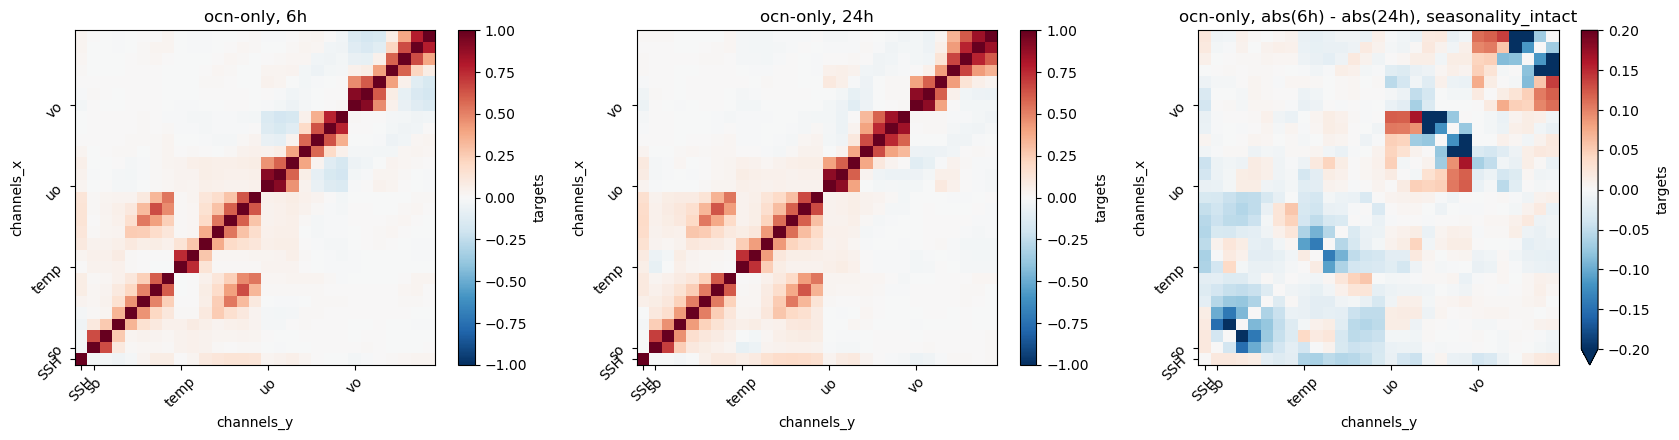

In [22]:
time_steps = ["6h", "24h"]
file_loc = "/global/homes/n/nagarwal/graph-ufs/prototypes/ocn_only"
seasonality_suffix = "seasonality_intact"

corr = {}

fig, ax = plt.subplots(1, 3, figsize=(17,4.5))

for i, ts in enumerate(time_steps):
    fname = f"tendency_correlation_ocn_only_{ts}_{seasonality_suffix}.nc"
    f = xr.open_dataset(os.path.join(file_loc, fname))
    corr[ts] = f.targets
    _ = plot_correlation(ax[i], corr[ts], meta=meta_targets,
                         title=f"ocn-only, {ts}")

# plot the difference in the third panel
diff = abs(corr["6h"]) - abs(corr["24h"])
_ = plot_correlation(ax[2], diff, meta=meta_targets,
                     title=f"ocn-only, abs(6h) - abs(24h), {seasonality_suffix}",
                     vmin=-0.2, vmax=0.2,
                    )

plt.tight_layout()
plt.savefig(f"./figures/compare_correlations_6h_24h_{seasonality_suffix}_diff_absolute_values.png", dpi=300)
plt.show()

## Compare seasonality removed vs seasonality intact covariances

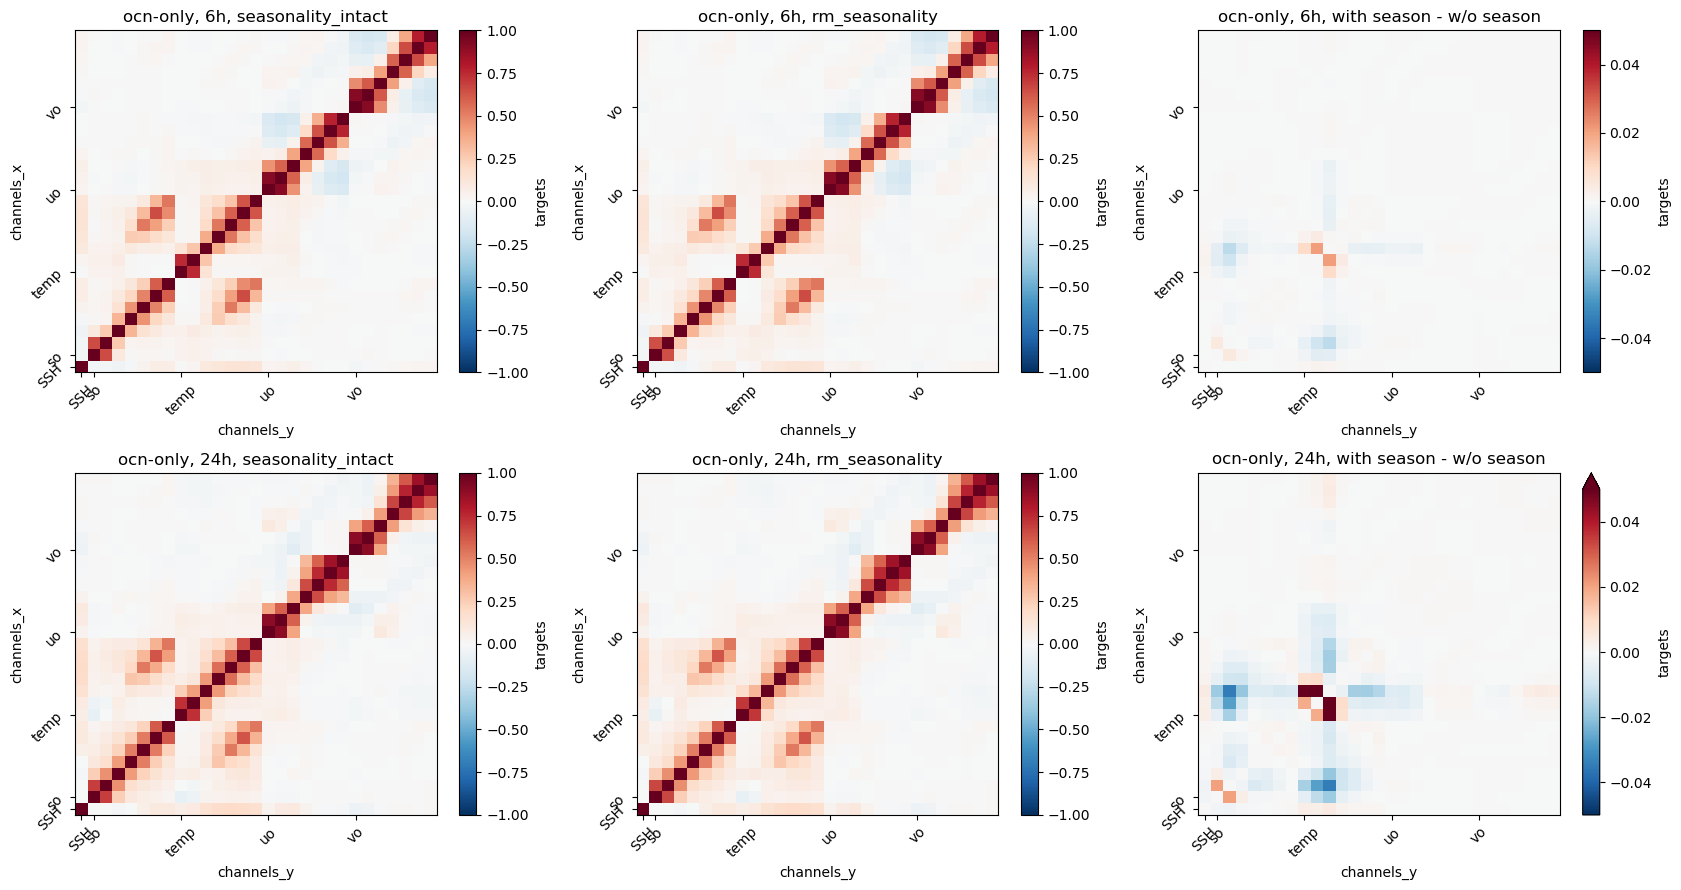

In [16]:
time_steps = ["6h", "24h"]
file_loc = "/global/homes/n/nagarwal/graph-ufs/prototypes/ocn_only"

files = {}
corr = {}

fig, ax = plt.subplots(len(time_steps), 3, figsize=(17,9))

for i, ts in enumerate(time_steps):

    files["seasonality_intact"] = f"tendency_correlation_ocn_only_{ts}_seasonality_intact.nc"
    files["rm_seasonality"] = f"tendency_correlation_ocn_only_{ts}_rm_seasonality.nc"
    
    for j, key in enumerate(list(files.keys())):
        f = xr.open_dataset(os.path.join(file_loc, files[key]))
        corr[key] = f.targets
        _ = plot_correlation(ax[i][j], corr[key], meta=meta_targets,
                             title=f"ocn-only, {ts}, {key}")

    # plot the difference in the third panel
    diff = corr["seasonality_intact"] - corr["rm_seasonality"]
    _ = plot_correlation(ax[i][2], diff, meta=meta_targets,
                         title=f"ocn-only, {ts}, with season - w/o season",
                         vmin=-0.05, vmax=0.05,
                         )

    files = {}
    
plt.tight_layout()
plt.savefig("./figures/compare_correlations_6h_24h_with_and_without_seasonality.png", dpi=300)
plt.show()

In [33]:
corr["seasonality_intact"].isel(channels_x=slice(8,11), channels_y=1).values

array([-0.08308747, -0.05688471,  0.03210913], dtype=float32)

In [34]:
corr["rm_seasonality"].isel(channels_x=slice(8,11), channels_y=1).values

array([-0.07822192, -0.04404007,  0.05039969])

# Compare any two given correlation matrices

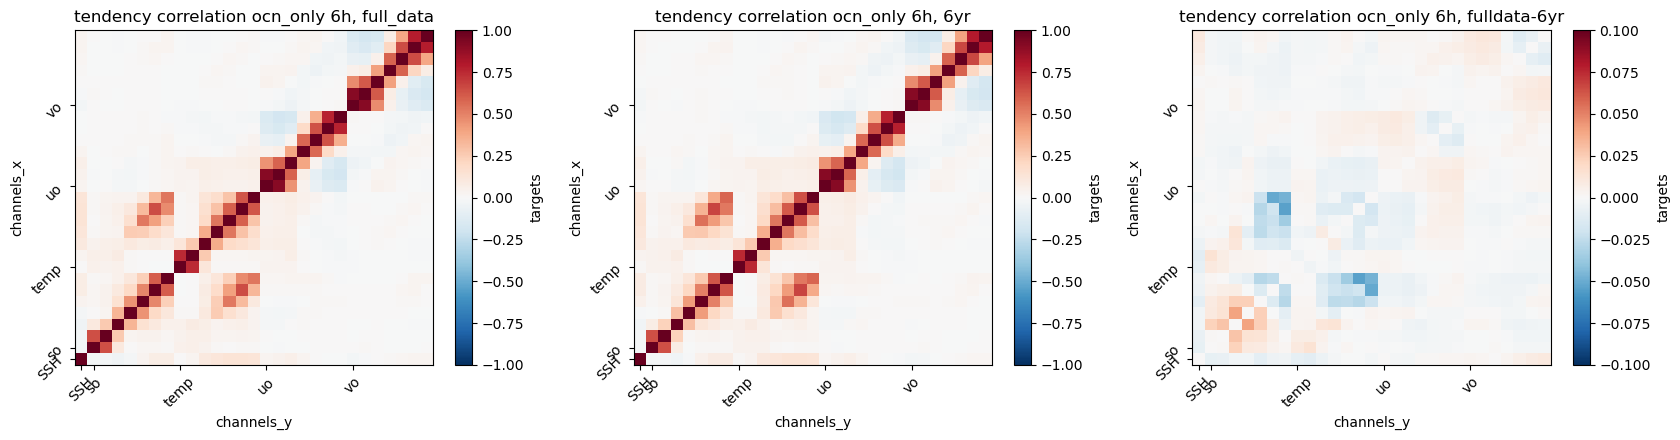

In [38]:
file_loc = "/global/homes/n/nagarwal/graph-ufs/prototypes/ocn_only"
corr = {}
files = {}

files["full_data"] = "tendency_correlation_ocn_only_6h_rm_seasonality.nc"
files["6yr"] = "tendency_correlation_ocn_only_6h_rm_seasonality_6yr_data.nc"

fig, ax = plt.subplots(1, len(files)+1, figsize=(17,4.5))

for i, key in enumerate(list(files.keys())):
    f = xr.open_dataset(os.path.join(file_loc, files[key]))
    corr[key] = f.targets
    _ = plot_correlation(ax[i], corr[key], meta=meta_targets,
                         title=f"tendency correlation ocn_only 6h, {key}")

# plot the difference in the third panel
diff = corr["full_data"] - corr["6yr"]
_ = plot_correlation(ax[2], diff, meta=meta_targets,
                     title="tendency correlation ocn_only 6h, fulldata-6yr",
                     vmin=-0.1, vmax=0.1,
                    )

plt.tight_layout()
plt.show()